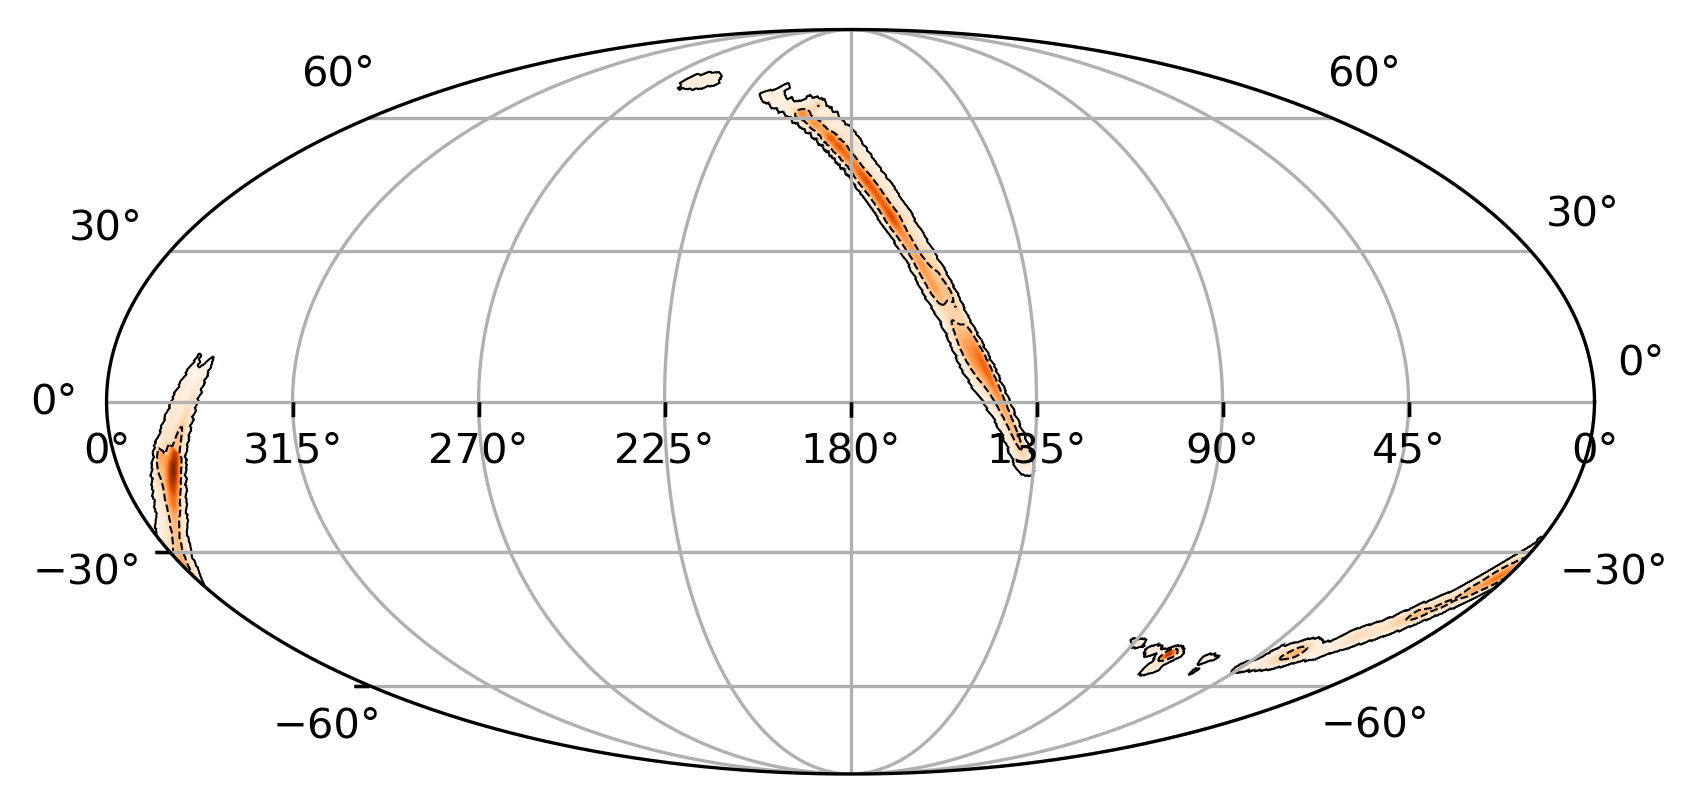

In [5]:
import ligo.skymap.io.fits
import ligo.skymap.postprocess.util
import numpy as np
import matplotlib.pyplot as pp
from matplotlib.colors import LogNorm
from matplotlib import cm
import ligo.skymap.plot

skymap, _ = ligo.skymap.io.fits.read_sky_map('/Users/samueleronchini/Downloads/bayestar.multiorder.fits,1', nest=True, distances=False)

fig = pp.figure(dpi=300)
ax = pp.axes(projection='astro degrees mollweide')
ax.grid()


cls = 100 * ligo.skymap.postprocess.util.find_greedy_credible_levels(skymap)

vmax = np.percentile(skymap[~np.isnan(skymap)], 99.0)
vmin = np.percentile(skymap[~np.isnan(skymap)], 10.0)
vmin = max(vmax/1e3, vmin)

skymap[cls > 90] = np.nan
skymap[skymap == 0] = np.nan


# ax.imshow_hpx((skymap, 'ICRS'), nested=True, cmap=cm.Oranges, norm=LogNorm(vmin=vmin, vmax=vmax), zorder=0)
ax.imshow_hpx((skymap, 'ICRS'), nested=True, cmap=cm.Oranges)
ax.contour_hpx((cls, 'ICRS'), nested=True, colors='black', levels=(50, 90), zorder=1, linestyles=['dashed', 'solid'], linewidths=0.5)



In [3]:
pp.show()